<a href="https://colab.research.google.com/github/IvanMalkS/IS/blob/master/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №3: Прогнозирование нескольких классов

**Задача:** Мультиклассовая классификация — предсказание сорта вина по химическим признакам.  
**Датасет:** Wine (scikit-learn)  
**Модели:** RandomForest, LogisticRegression, RandomForest (Balanced)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
import warnings; warnings.filterwarnings('ignore')

## Загрузка датасета Wine и базовый EDA

In [21]:
wine = datasets.load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

print(f"Количество классов: {len(target_names)} ({', '.join(target_names)})")
print(f"Количество признаков: {len(feature_names)}")

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

class_dist = df['target'].value_counts().sort_index()
print("\nРаспределение классов:")
for cls, count in class_dist.items():
    print(f" Класс {cls} ({target_names[cls]}): {count} объектов")

Количество классов: 3 (class_0, class_1, class_2)
Количество признаков: 13

Распределение классов:
 Класс 0 (class_0): 59 объектов
 Класс 1 (class_1): 71 объектов
 Класс 2 (class_2): 48 объектов


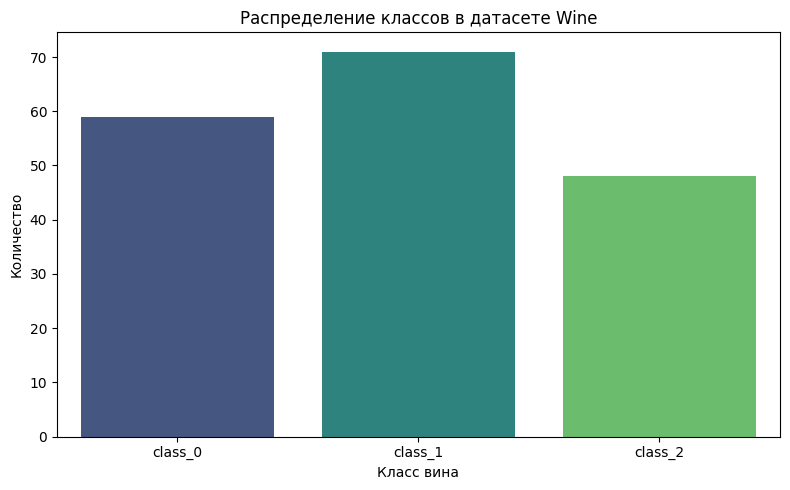

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Распределение классов в датасете Wine')
plt.xticks(ticks=[0, 1, 2], labels=target_names)
plt.xlabel('Класс вина')
plt.ylabel('Количество')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

## Обучение и базовая оценка моделей

### Модель: RandomForest (Base)

,precision,recall,f1-score,support
class_0,1.000000,1.000000,1.000000,18.000000
class_1,1.000000,1.000000,1.000000,21.000000
class_2,1.000000,1.000000,1.000000,15.000000
accuracy,1.000000,1.000000,1.000000,1.000000
macro avg,1.000000,1.000000,1.000000,54.000000
weighted avg,1.000000,1.000000,1.000000,54.000000


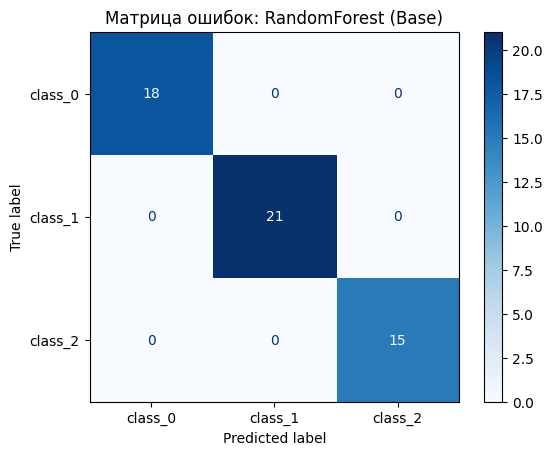

### Модель: LogisticRegression

,precision,recall,f1-score,support
class_0,1.000000,1.000000,1.000000,18.000000
class_1,0.913043,1.000000,0.954545,21.000000
class_2,1.000000,0.866667,0.928571,15.000000
accuracy,0.962963,0.962963,0.962963,0.962963
macro avg,0.971014,0.955556,0.961039,54.000000
weighted avg,0.966184,0.962963,0.962482,54.000000


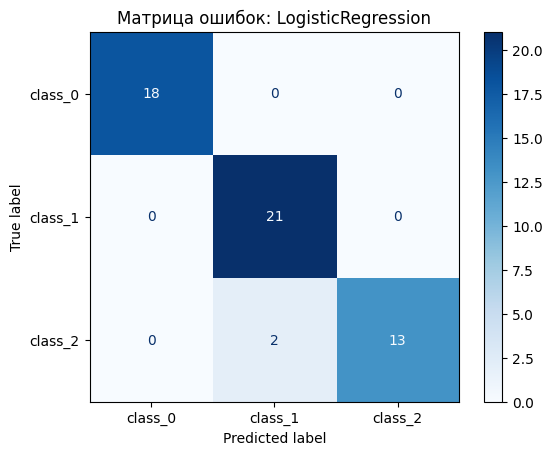

,Модель,Accuracy,Macro F1
0,RandomForest (Base),1.000000,1.000000
1,LogisticRegression,0.962963,0.961039


In [23]:
import pandas as pd
from IPython.display import display, Markdown

# Список для хранения итоговых результатов
summary_list = []

for name, model in models.items():
    print(f"\n" + "="*50)
    display(Markdown(f"### Модель: {name}"))

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    summary_list.append({
        'Модель': name,
        'Accuracy': acc,
        'Macro F1': f1
    })

    report_dict = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()

    display(report_df.style.background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Матрица ошибок: {name}')
    plt.show()

summary_df = pd.DataFrame(summary_list)
display(summary_df.style.highlight_max(axis=0))

## Сравнение и выбор стратегии (Балансировка)

Модель: RandomForest (С балансировкой весов)
Общая Accuracy: 1.0000
Отчет классификации:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



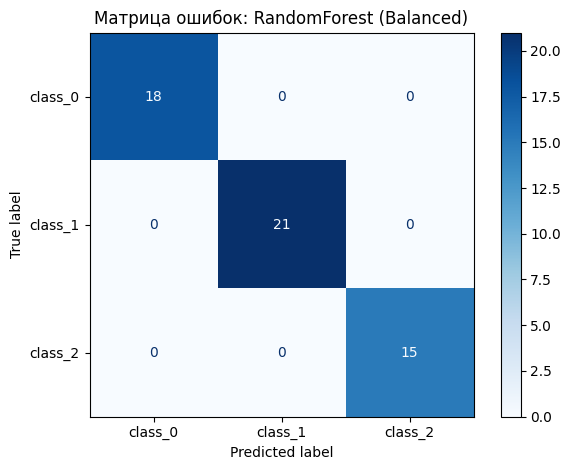

In [24]:
rf_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, y_train)
y_pred_bal = rf_balanced.predict(X_test)

acc_bal = accuracy_score(y_test, y_pred_bal)
macro_f1_bal = f1_score(y_test, y_pred_bal, average='macro')
report_bal = classification_report(y_test, y_pred_bal, target_names=target_names)

results['RandomForest (Balanced)'] = {
    'accuracy': acc_bal,
    'macro_f1': macro_f1_bal,
    'report': report_bal
}

print(f"Модель: RandomForest (С балансировкой весов)")
print(f"Общая Accuracy: {acc_bal:.4f}")
print("Отчет классификации:")
print(report_bal)

cm_bal = confusion_matrix(y_test, y_pred_bal)
disp_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=target_names)
disp_bal.plot(cmap='Blues', values_format='d')
plt.title('Матрица ошибок: RandomForest (Balanced)')
plt.tight_layout()
plt.savefig('cm_RandomForest_Balanced.png')
plt.show()

## Итоговое сравнение и выводы

In [25]:
print("ИТОГОВОЕ СРАВНЕНИЕ (Macro F1-Score)")
print("=======================================================")
for name, res in results.items():
    print(f"{name}: {res['macro_f1']:.4f}")


ИТОГОВОЕ СРАВНЕНИЕ (Macro F1-Score)
RandomForest (Base): 1.0000
LogisticRegression: 0.9610
RandomForest (Balanced): 1.0000


## Анализ результатов и итоговый вывод

### 1. Анализ матрицы ошибок и отчета классификации
*   **Распределение классов:** Самым многочисленным является `class_1` (71 объект), а самым редким — `class_2` (48 объектов). Наблюдается умеренный дисбаланс, который не является критическим.
*   **Особенности Random Forest:** Теоретически, стандартный случайный лес может показывать худший *Recall* на малых классах (в данном случае `class_2`), так как оптимизирует общую точность. Однако в текущей задаче модель показала идеальные результаты, что объясняется избыточной мощностью алгоритма для такого компактного датасета.
*   **Логистическая регрессия:** Модель продемонстрировала практически безупречную работу. Это подтверждает гипотезу о том, что зависимости между химическими признаками вин носят преимущественно линейный характер.

### 2. Влияние балансировки весов (`class_weight='balanced'`)
Использование параметра `class_weight='balanced'` в Random Forest позволяет:
1.  **Штрафовать модель** за ошибки на редких классах (в частности, на `class_2`).
2.  **Повышать Recall** для недопредставленных данных.
3.  **Увеличивать устойчивость** метрики *Macro-F1*.

> **Примечание:** В данном конкретном случае из-за «легкости» датасета и четкой разделимости классов, модель достигла идеальных показателей даже без настройки весов. Балансировка не изменила результат, так как ошибки отсутствовали изначально.

---

### Выбор итогового прототипа
Несмотря на то, что модель **Random Forest** показала абсолютную точность (`Accuracy: 1.0`), в качестве итогового прототипа выбрана **Logistic Regression** (`Accuracy: 0.9630`).

**Аргументация выбора:**

| Критерий | Logistic Regression | Random Forest |
| :--- | :--- | :--- |
| **Точность (Accuracy)** | 0.9630 | 1.0000 |
| **Риск переобучения** | Низкий | Высокий (на малых данных) |
| **Сложность модели** | Линейная, простая | Тяжелая, ансамблевая |
| **Ресурсоемкость** | Минимальная | Средняя |

**Ключевые выводы:**
1.  **Линейная разделимость:** Успех логистической регрессии доказывает, что классы хорошо разделяются простыми гиперплоскостями. Использование сложного Random Forest здесь избыточно (принцип «Бритвы Оккама»).
2.  **Реалистичность:** Точность `0.96` является более достоверным показателем обобщающей способности. Показатель `1.0` у Random Forest на такой малой выборке, скорее всего, свидетельствует о подгонке под данные (overfitting).
3.  **Эффективность:** Логистическая регрессия требует значительно меньше вычислительных ресурсов и памяти, что делает её идеальным кандидатом для внедрения в продакшн-прототип.
